In [ ]:
## defined the data set
flight_data = pd.read_csv("flights.csv")

In [ ]:
## defined the data set
flight_data = pd.read_csv("flights.csv")

In [ ]:
##import all libraries
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
## defined the data set
flight_data = pd.read_csv("flights.csv")

In [ ]:
## show the data set
flight_data

In [ ]:
## information about data set
flight_data.info()

In [ ]:
## calculate the number of missing values
flight_data.isna().sum()

In [ ]:
##delete all null values
flight_data.dropna()

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,name
0,0,2013.0,1.0,1.0,517.0,515.0,2.0,830.0,819.0,11.0,...,1545.0,N14228,EWR,IAH,227.0,1400.0,5.0,15.0,2013-01-01 05:00:00,United Air Lines Inc.
1,1,2013.0,1.0,1.0,533.0,529.0,4.0,850.0,830.0,20.0,...,1714.0,N24211,LGA,IAH,227.0,1416.0,5.0,29.0,2013-01-01 05:00:00,United Air Lines Inc.
2,2,2013.0,1.0,1.0,542.0,540.0,2.0,923.0,850.0,33.0,...,1141.0,N619AA,JFK,MIA,160.0,1089.0,5.0,40.0,2013-01-01 05:00:00,American Airlines Inc.
3,3,2013.0,1.0,1.0,544.0,545.0,-1.0,1004.0,1022.0,-18.0,...,725.0,N804JB,JFK,BQN,183.0,1576.0,5.0,45.0,2013-01-01 05:00:00,JetBlue Airways
4,4,2013.0,1.0,1.0,554.0,600.0,-6.0,812.0,837.0,-25.0,...,461.0,N668DN,LGA,ATL,116.0,762.0,6.0,0.0,2013-01-01 06:00:00,Delta Air Lines Inc.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74221,74221,2013.0,11.0,20.0,1818.0,1700.0,78.0,2127.0,1958.0,89.0,...,1585.0,N332NB,LGA,MCO,134.0,950.0,17.0,0.0,2013-11-20 17:00:00,Delta Air Lines Inc.
74222,74222,2013.0,11.0,20.0,1820.0,1820.0,0.0,2120.0,2150.0,-30.0,...,442.0,N187DN,JFK,SEA,322.0,2422.0,18.0,20.0,2013-11-20 18:00:00,Delta Air Lines Inc.
74223,74223,2013.0,11.0,20.0,1821.0,1829.0,-8.0,2004.0,2033.0,-29.0,...,1751.0,N191UW,EWR,CLT,72.0,529.0,18.0,29.0,2013-11-20 18:00:00,US Airways Inc.
74224,74224,2013.0,11.0,20.0,1822.0,1830.0,-8.0,2031.0,2047.0,-16.0,...,415.0,N939DL,JFK,DTW,83.0,509.0,18.0,30.0,2013-11-20 18:00:00,Delta Air Lines Inc.


**1.What is the most common carrier/flight airline in this data set?**

In [ ]:
carrier_count = flight_data["carrier"].value_counts() ## using value counts to count carrier()
carrier_count

carrier
UA    10039
EV     9375
B6     9111
DL     8067
AA     5705
MQ     4633
US     3569
9E     3352
WN     2156
VX      819
FL      580
AS      129
F9      122
YV      116
HA       55
OO        1
Name: count, dtype: int64

In [ ]:
print("the most common carrier is :" ,carrier_count.idxmax())

the most common carrier is : UA


AttributeError: module 'matplotlib.pyplot' has no attribute 'xlable'

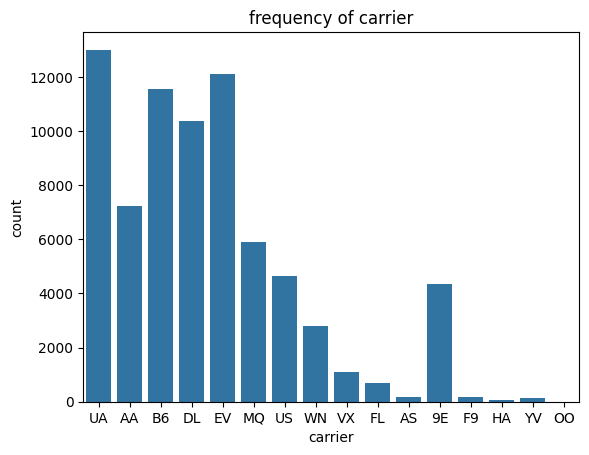

In [ ]:
sns.countplot(x="carrier", data =flight_data)
plt.title("frequency of carrier")
plt.xlable("Carrier")
plt.ylabel("flights")

**2. What is the most commonly used tailnum?** // ماهي الطائرة الاكثر استخداما

In [ ]:
tailnum_count= flight_data["tailnum"].value_counts()
tailnum_count


tailnum
N730MQ    44
N739MQ    44
N719MQ    44
N713MQ    42
N723MQ    42
          ..
N358AA     1
N176AT     1
N393DA     1
N537AS     1
N133EV     1
Name: count, Length: 2872, dtype: int64

In [ ]:
print("the most common aircraft is :",tailnum_count.idxmax())

the most common aircraft is : N730MQ


**3.Do you have more flights in the morning, afternoon or evening ?**

Text(0, 0.5, '')

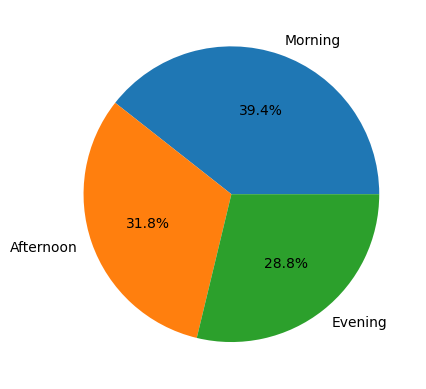

In [ ]:
def time_of_day(x):
    if x < 12:
        return "Morning"
    elif x < 17:
        return "Afternoon"
    else:
        return "Evening"


flight_data["time_of_day"] = flight_data["hour"].apply(time_of_day)
flight_data["time_of_day"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.xlabel("")
plt.ylabel("")


Text(0, 0.5, 'Number of Flights')

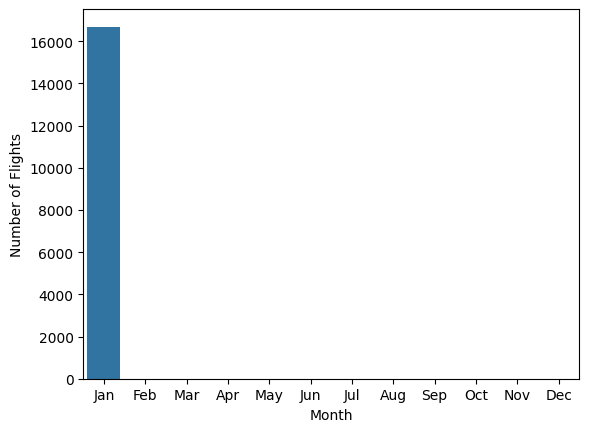

In [ ]:
# Months with the most flights, sorted by month number
year_map = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec",
}

'''
Here we add a new column to the flight data (flight_data) called month_name. This column is populated using the map function,
which replaces the numbers in the month column with the corresponding names of the months using the year_map dictionary.
'''

flight_data["month_name"] = flight_data["month"].map(year_map)
sns.countplot(x="month_name", data=flight_data, order=year_map.values())
plt.xlabel("Month")
plt.ylabel("Number of Flights")


**4.Do people fly more during th weekends(friday,saturday,sunday)**

Text(0, 0.5, 'Number of Flights')

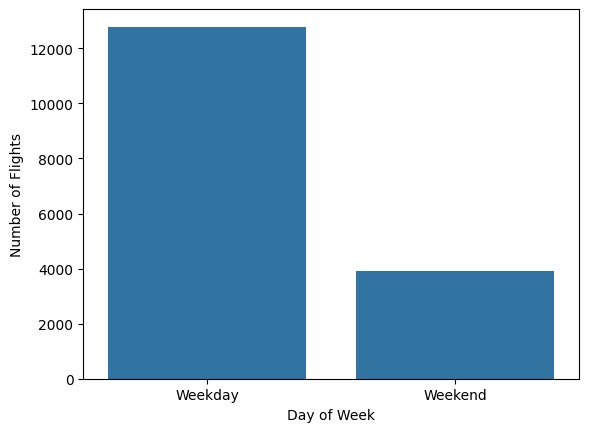

In [ ]:
# Merge year, month, day into one date column
flight_data["date"] = pd.to_datetime(flight_data[["year", "month", "day"]])
# Categorize date into Weekday and Weekend
flight_data["day_of_week"] = flight_data["date"].dt.dayofweek.apply(
    lambda x: "Weekday" if x < 5 else "Weekend"
)

# Plot weekday vs weekend flights
sns.countplot(x="day_of_week", data=flight_data)
plt.xlabel("Day of Week")
plt.ylabel("Number of Flights")

**5.Which airline has the most delays?**

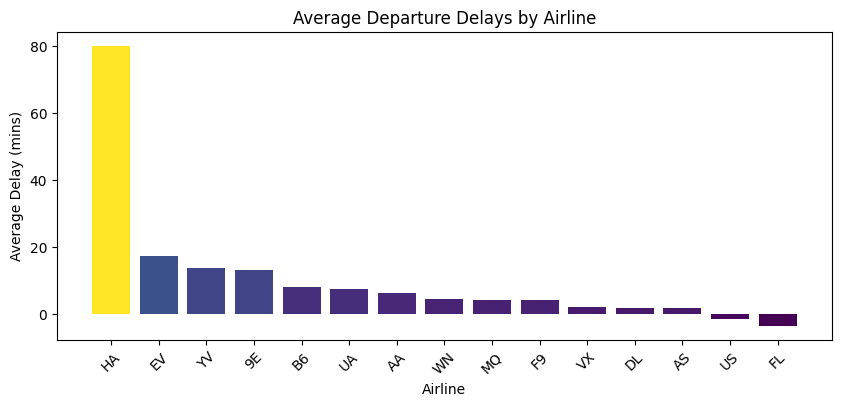

In [ ]:

average_delays = flight_data.groupby("carrier")["dep_delay"].mean().sort_values(ascending=False)

# Set up bar using matplotlib with color gradient
plt.figure(figsize=(10,4))

norm = plt.Normalize(average_delays.min(), average_delays.max())
colors = plt.cm.viridis(norm(average_delays.values))

bars = plt.bar(average_delays.index, average_delays.values, color=colors)

plt.xlabel("Airline")
plt.ylabel("Average Delay (mins)")
plt.title("Average Departure Delays by Airline")
plt.xticks(rotation=45)


plt.show()